<a href="https://colab.research.google.com/github/astridmeilendra/PBA-WondrByBNI-Sentimen/blob/main/Astrid_ScrapReviewNHSApp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install library (jalankan sekali saja)
!pip install google_play_scraper
!pip install textblob

# Import modul
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
# from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Konfigurasi matplotlib
%matplotlib inline
%config InlineBackend.figure_format='retina'

# Ganti style seaborn lama dengan yang valid
plt.style.use('seaborn-v0_8')
plt.rcParams["figure.figsize"] = (15,10)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.5 MB/s eta 0:00:00


In [2]:
#Android App NHS link from Google Play at
#https://play.google.com/store/apps/details?id=uk.nhs.covid19.production&hl=en_GB&gl=US
#The apps ID found in the link after id=uk.nhs.covid19.production
#The apps name on Google Play titled: NHS COVID-19 Department of Health and Social Care, UK Government
#Dated 17 April 2022: number of reviews 134,397

from google_play_scraper import app, Sort, reviews_all

wondr_reviews = reviews_all(
    'id.bni.wondr',               # ID aplikasi Wondr by BNI
    sleep_milliseconds=0,
    lang='id',                    # bahasa Indonesia
    sort=Sort.NEWEST,             # bisa diganti Sort.MOST_RELEVANT
)

In [3]:
# 1. Import library
import pandas as pd
import numpy as np

# 2. Buat dataframe dari wondr_reviews
df_wondrrev = pd.DataFrame(np.array(wondr_reviews), columns=['content'])
df_wondrrev = df_wondrrev.join(pd.DataFrame(df_wondrrev.pop('content').tolist()))

# 3. Simpan ke folder kerja Colab (/content)
df_wondrrev.to_csv('/content/df_wondrrev.csv', index=False)

# 4. Cek apakah file tersimpan
import os
print(os.listdir('/content'))

# 5. Baca kembali file CSV
df_wondrrev = pd.read_csv('/content/df_wondrrev.csv')

# 6. Tampilkan 5 baris pertama
print(df_wondrrev.head())

# 7. Download file ke laptop
from google.colab import files
files.download('/content/df_wondrrev.csv')



['.config', 'df_wondrrev.csv', 'sample_data']
                               reviewId         userName  \
0  8ca8711d-7065-4725-8605-c2250f21ad51  Pengguna Google   
1  75f73e35-fba5-413d-950d-c074b0af0a4a  Pengguna Google   
2  b7da8673-2888-4fdc-870d-4b0496ac85f1  Pengguna Google   
3  6ef5fa85-0260-40ca-95dc-ed5bcdab48f4  Pengguna Google   
4  f993f3fa-6843-4baa-a8f9-da1b238329f9  Pengguna Google   

                                           userImage                  content  \
0  https://play-lh.googleusercontent.com/EGemoI2N...                    bagus   
1  https://play-lh.googleusercontent.com/EGemoI2N...                   mantap   
2  https://play-lh.googleusercontent.com/EGemoI2N...  bermanfaat cepat akurat   
3  https://play-lh.googleusercontent.com/EGemoI2N...   sangat membantu sekali   
4  https://play-lh.googleusercontent.com/EGemoI2N...                     bgus   

   score  thumbsUpCount reviewCreatedVersion                   at  \
0      5              0              

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
print(df_wondrrev.reviewCreatedVersion.unique())
print(df_wondrrev.reviewCreatedVersion.nunique())

['1.5.0' '1.4.4' nan '1.3.1' '1.3.2' '1.4.3' '1.4.2' '1.2.0' '1.4.1'
 '1.0.3' '1.3.0' '1.0.2' '1.4.0' '1.0.1' '0.1.4']
14


In [6]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_wondrrev.loc[:, ["content", "score", "thumbsUpCount",
                    "reviewCreatedVersion", "at",
                    "replyContent", "repliedAt"]]


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,bagus,5,0,1.5.0,2026-03-31 01:23:04,NaN,NaN
1,mantap,5,0,1.5.0,2026-03-31 01:15:53,NaN,NaN
2,bermanfaat cepat akurat,5,0,1.5.0,2026-03-31 01:11:11,NaN,NaN
3,sangat membantu sekali,5,0,1.5.0,2026-03-31 01:00:31,NaN,NaN
4,bgus,5,0,1.5.0,2026-03-31 00:47:11,NaN,NaN
...,...,...,...,...,...,...,...
88798,Simpel..mantab,5,2,1.0.1,2024-07-01 02:47:55,NaN,NaN
88799,Makin simple dan lengkap. Terkoneksi dengan al...,5,22,1.0.1,2024-07-01 02:45:01,NaN,NaN
88800,Tampilannya keren👏👏,5,3,1.0.1,2024-07-01 02:43:33,NaN,NaN
88801,Canggih...,5,2,1.0.1,2024-07-01 02:33:41,NaN,NaN


In [7]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.1 MB/s eta 0:00:00


In [8]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
df_wondrrev['sentiment_polarity'] = df_wondrrev['content'].apply(lambda x: TextBlob(x).polarity)
df_wondrrev['sentiment_subjective'] = df_wondrrev['content'].apply(lambda x: TextBlob(x).subjectivity)


In [9]:
#df_wondrrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","at"]]
df_wondrrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]


,content,score,sentiment_polarity,sentiment_subjective
0,bagus,5,0.0,0.000000
1,mantap,5,0.0,0.000000
2,bermanfaat cepat akurat,5,0.0,0.000000
3,sangat membantu sekali,5,0.0,0.000000
4,bgus,5,0.0,0.000000
...,...,...,...,...
88798,Simpel..mantab,5,0.0,0.000000
88799,Makin simple dan lengkap. Terkoneksi dengan all sumber dana baik debet dan kredit. Makin keren,5,0.0,0.357143
88800,Tampilannya keren👏👏,5,0.0,0.000000
88801,Canggih...,5,0.0,0.000000


In [10]:
#Check number of reviews scores
df_wondrrev['score'].value_counts()


,count
score,
5,59265
1,15878
4,5536
3,4288
2,3836


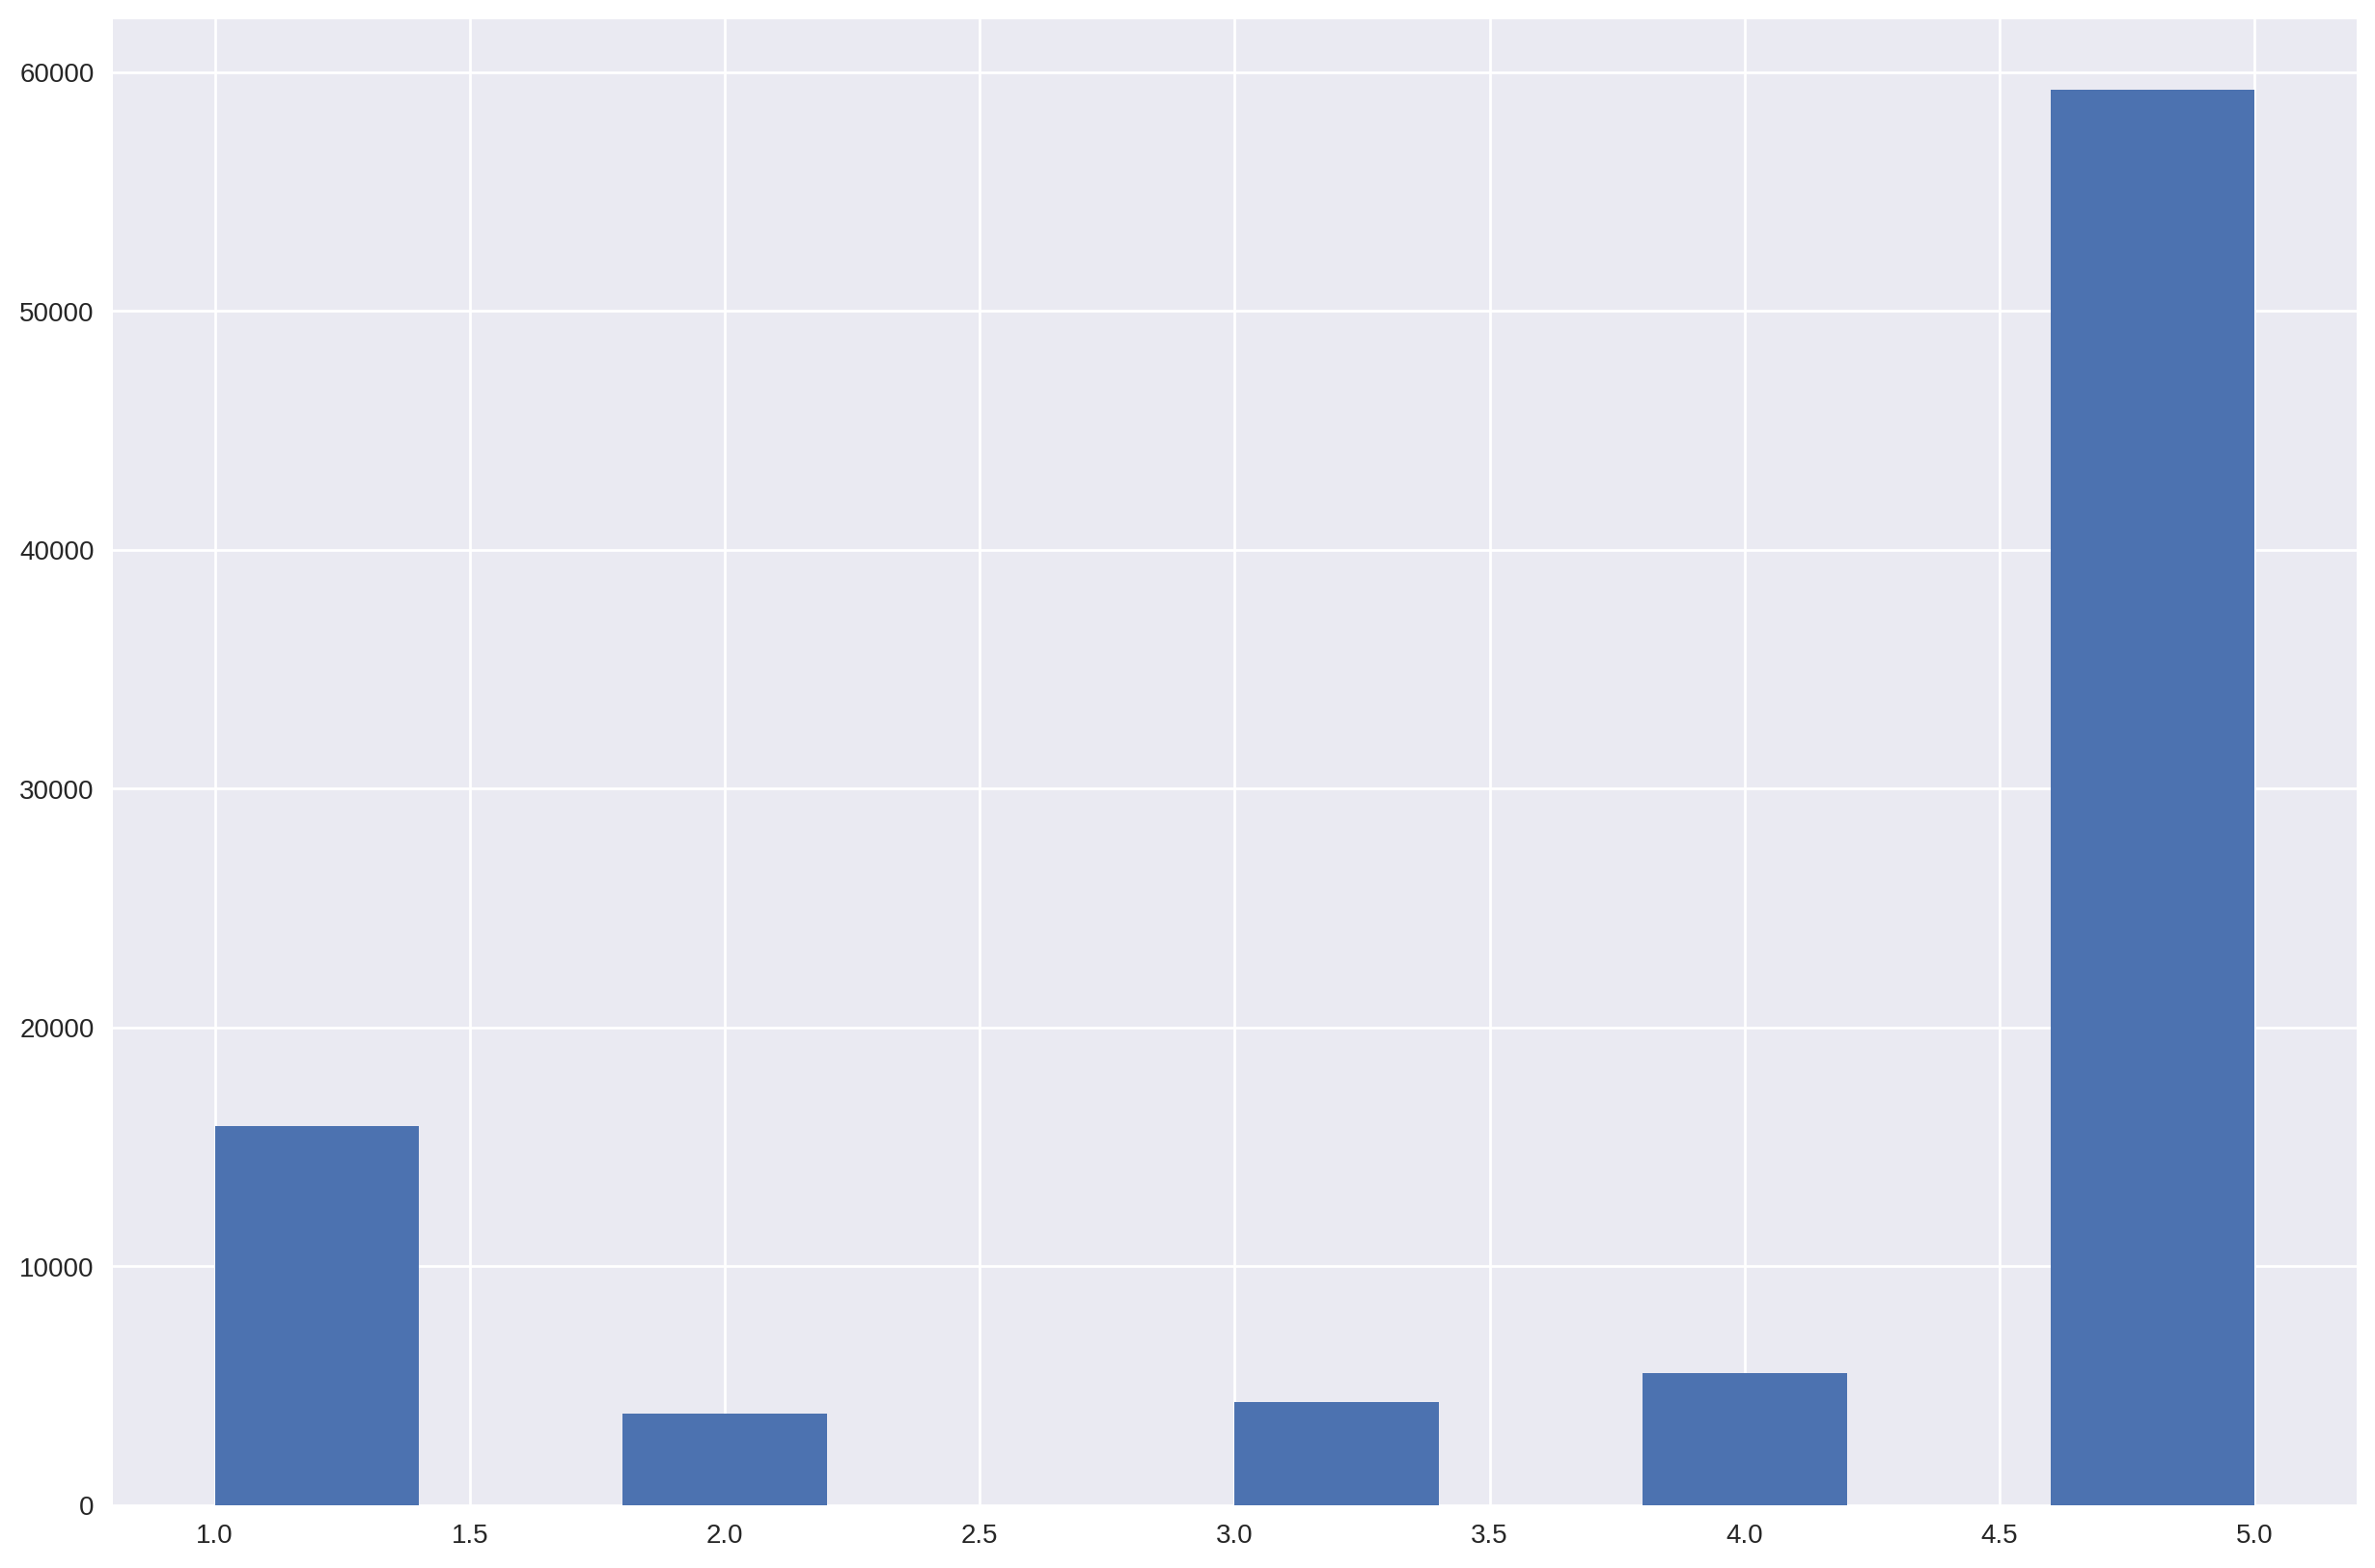

In [11]:
plt.hist(df_wondrrev['score'])
plt.show()


In [12]:
#DATA PREPROCESSING
# Lower casing

# Change the reviews type to string
df_wondrrev['content'] = df_wondrrev['content'].astype(str) # Before lowercasing
# Before lowercasing
print(df_wondrrev['content'][224])   # contoh index, sesuaikan dengan jumlah data

bos transaksi transferan gagal, tpi saldo udh terpotong, kok smpek skrg blom balek saldo nya


In [13]:
# Lowercase all reviews to see the difference
df_wondrrev['content'] = df_wondrrev['content'].apply(lambda x: x.lower())

# Contoh print salah satu review (sesuaikan index dengan jumlah data yang ada)
print(df_wondrrev['content'][224])


bos transaksi transferan gagal, tpi saldo udh terpotong, kok smpek skrg blom balek saldo nya


In [14]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [15]:
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_wondrrev['wordCount'] = [len(review.split()) for review in df_wondrrev['content']]

df_wondrrev['uppercaseCharCount'] = [sum(char.isupper() for char in review)
                                     for review in df_wondrrev['content']]

df_wondrrev['specialCharCount'] = [sum(char in string.punctuation for char in review)
                                   for review in df_wondrrev['content']]


In [16]:
df_wondrrev.loc[:, ["content", "score", "sentiment_polarity",
                    "sentiment_subjective", "wordCount",
                    "uppercaseCharCount", "specialCharCount"]]


,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,bagus,5,0.0,0.000000,1,0,0
1,mantap,5,0.0,0.000000,1,0,0
2,bermanfaat cepat akurat,5,0.0,0.000000,3,0,0
3,sangat membantu sekali,5,0.0,0.000000,3,0,0
4,bgus,5,0.0,0.000000,1,0,0
...,...,...,...,...,...,...,...
88798,simpel..mantab,5,0.0,0.000000,1,0,2
88799,makin simple dan lengkap. terkoneksi dengan all sumber dana baik debet dan kredit. makin keren,5,0.0,0.357143,15,0,2
88800,tampilannya keren👏👏,5,0.0,0.000000,2,0,0
88801,canggih...,5,0.0,0.000000,1,0,3


In [17]:
#Removing stopwords
#Using nltk
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, sent_tokenize
from nltk import FreqDist
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer


from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

from string import punctuation

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [18]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  ax = sns.barplot(data=d, x= "word", y = "count")
  ax.set(ylabel = 'Count')
  plt.show()

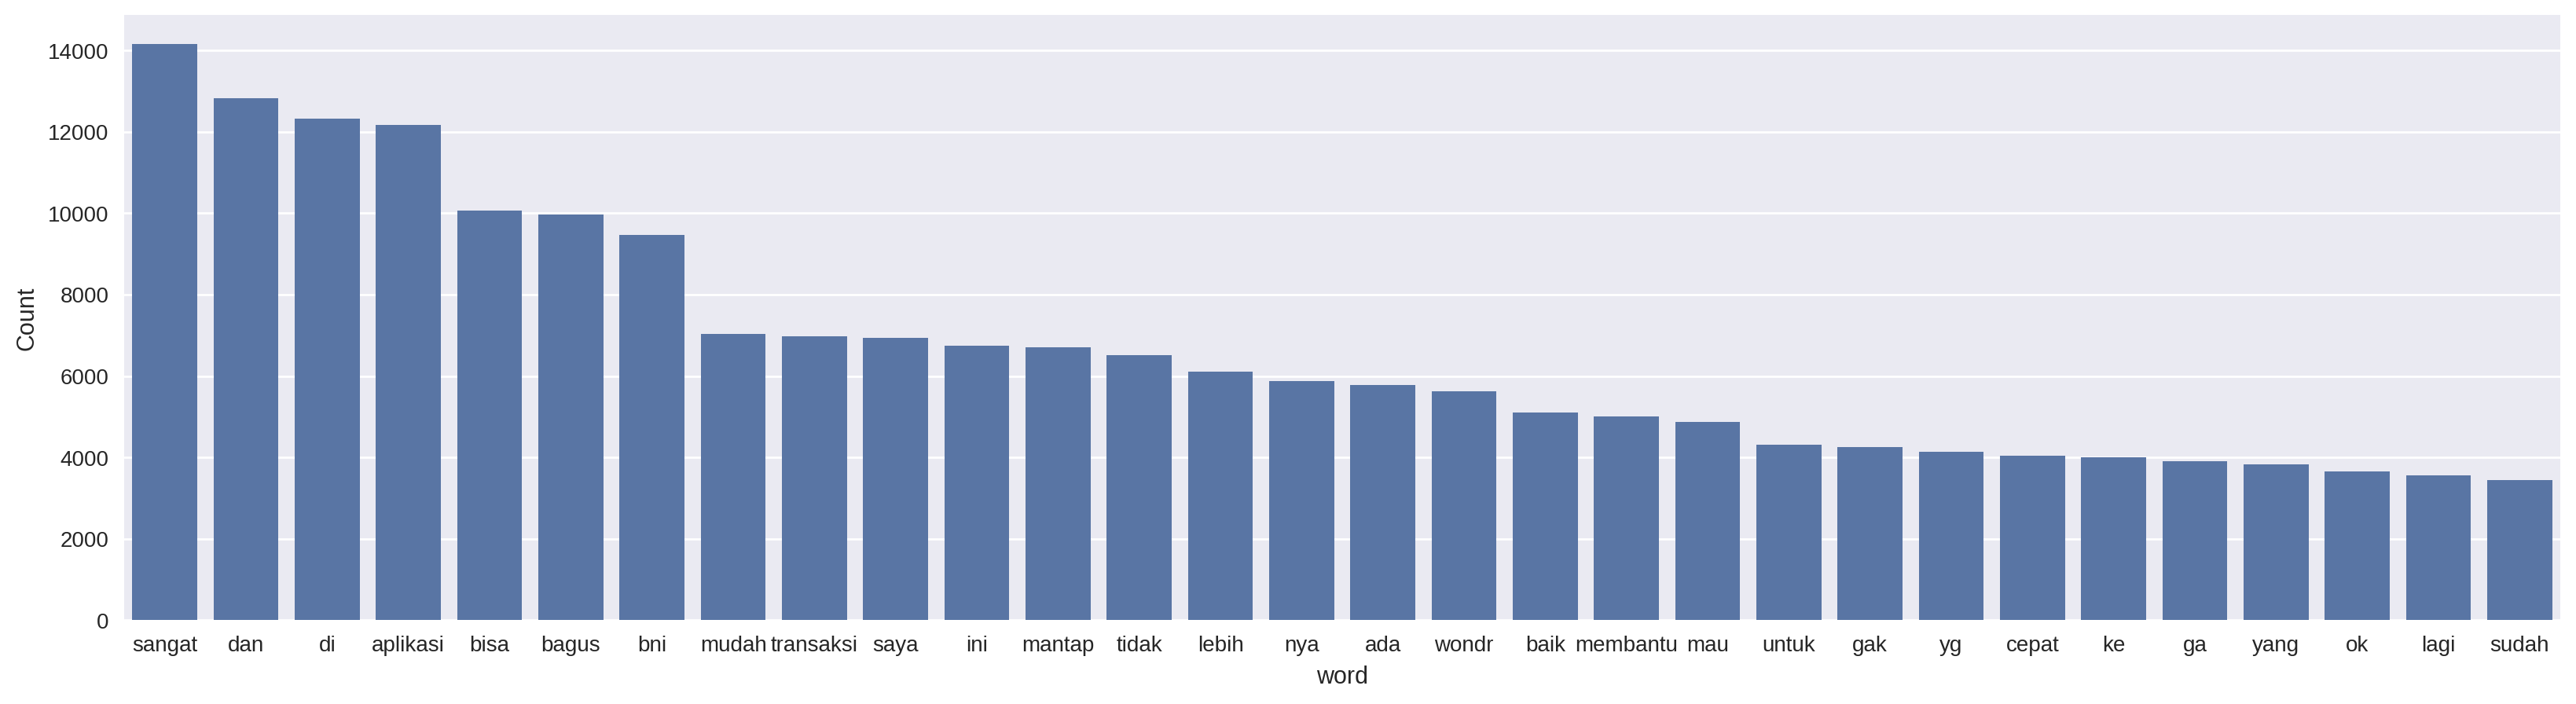

In [19]:
freq_words(df_wondrrev['content'])

In [20]:
#check if there is any special character
alphabet = string.ascii_letters + string.punctuation
print(df_wondrrev.content.str.strip(alphabet).astype(bool).any())

extracted_emojis = []

def extract_emojis(s):
    expe = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)
    return expe.findall(s)

for y in df_wondrrev['content']:
    extracted_emojis.append(str(extract_emojis(y)))

print(extracted_emojis)


True
['[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['👍', '👍', '👍']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['😭', '😭', '😭', '😭', '😭', '😭', '😭', '😭']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['👍', '🙏', '🙂']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['😡', '😡', '😡']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['👍', '👍', '👍', '👍']", '[]', '[]', '[]', '[]', '[]', '[]', "['😑']", '[]', '[

In [21]:
df_wondrrev.loc[:, ["content","score","sentiment_polarity",
                    "sentiment_subjective","wordCount",
                    "uppercaseCharCount","specialCharCount"]]


,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,bagus,5,0.0,0.000000,1,0,0
1,mantap,5,0.0,0.000000,1,0,0
2,bermanfaat cepat akurat,5,0.0,0.000000,3,0,0
3,sangat membantu sekali,5,0.0,0.000000,3,0,0
4,bgus,5,0.0,0.000000,1,0,0
...,...,...,...,...,...,...,...
88798,simpel..mantab,5,0.0,0.000000,1,0,2
88799,makin simple dan lengkap. terkoneksi dengan all sumber dana baik debet dan kredit. makin keren,5,0.0,0.357143,15,0,2
88800,tampilannya keren👏👏,5,0.0,0.000000,2,0,0
88801,canggih...,5,0.0,0.000000,1,0,3


In [22]:
# Add a column sentiment_rating berdasarkan score
df_wondrrev['sentiment_rating'] = df_wondrrev['score'].apply(
    lambda x: 'Positive' if x > 3 else ('Neutral' if x == 3 else 'Negative')
)


In [23]:
df_wondrrev.loc[:, ["content","score","sentiment_polarity",
                    "sentiment_subjective","sentiment_rating"]]


,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,bagus,5,0.0,0.000000,Positive
1,mantap,5,0.0,0.000000,Positive
2,bermanfaat cepat akurat,5,0.0,0.000000,Positive
3,sangat membantu sekali,5,0.0,0.000000,Positive
4,bgus,5,0.0,0.000000,Positive
...,...,...,...,...,...
88798,simpel..mantab,5,0.0,0.000000,Positive
88799,makin simple dan lengkap. terkoneksi dengan all sumber dana baik debet dan kredit. makin keren,5,0.0,0.357143,Positive
88800,tampilannya keren👏👏,5,0.0,0.000000,Positive
88801,canggih...,5,0.0,0.000000,Positive


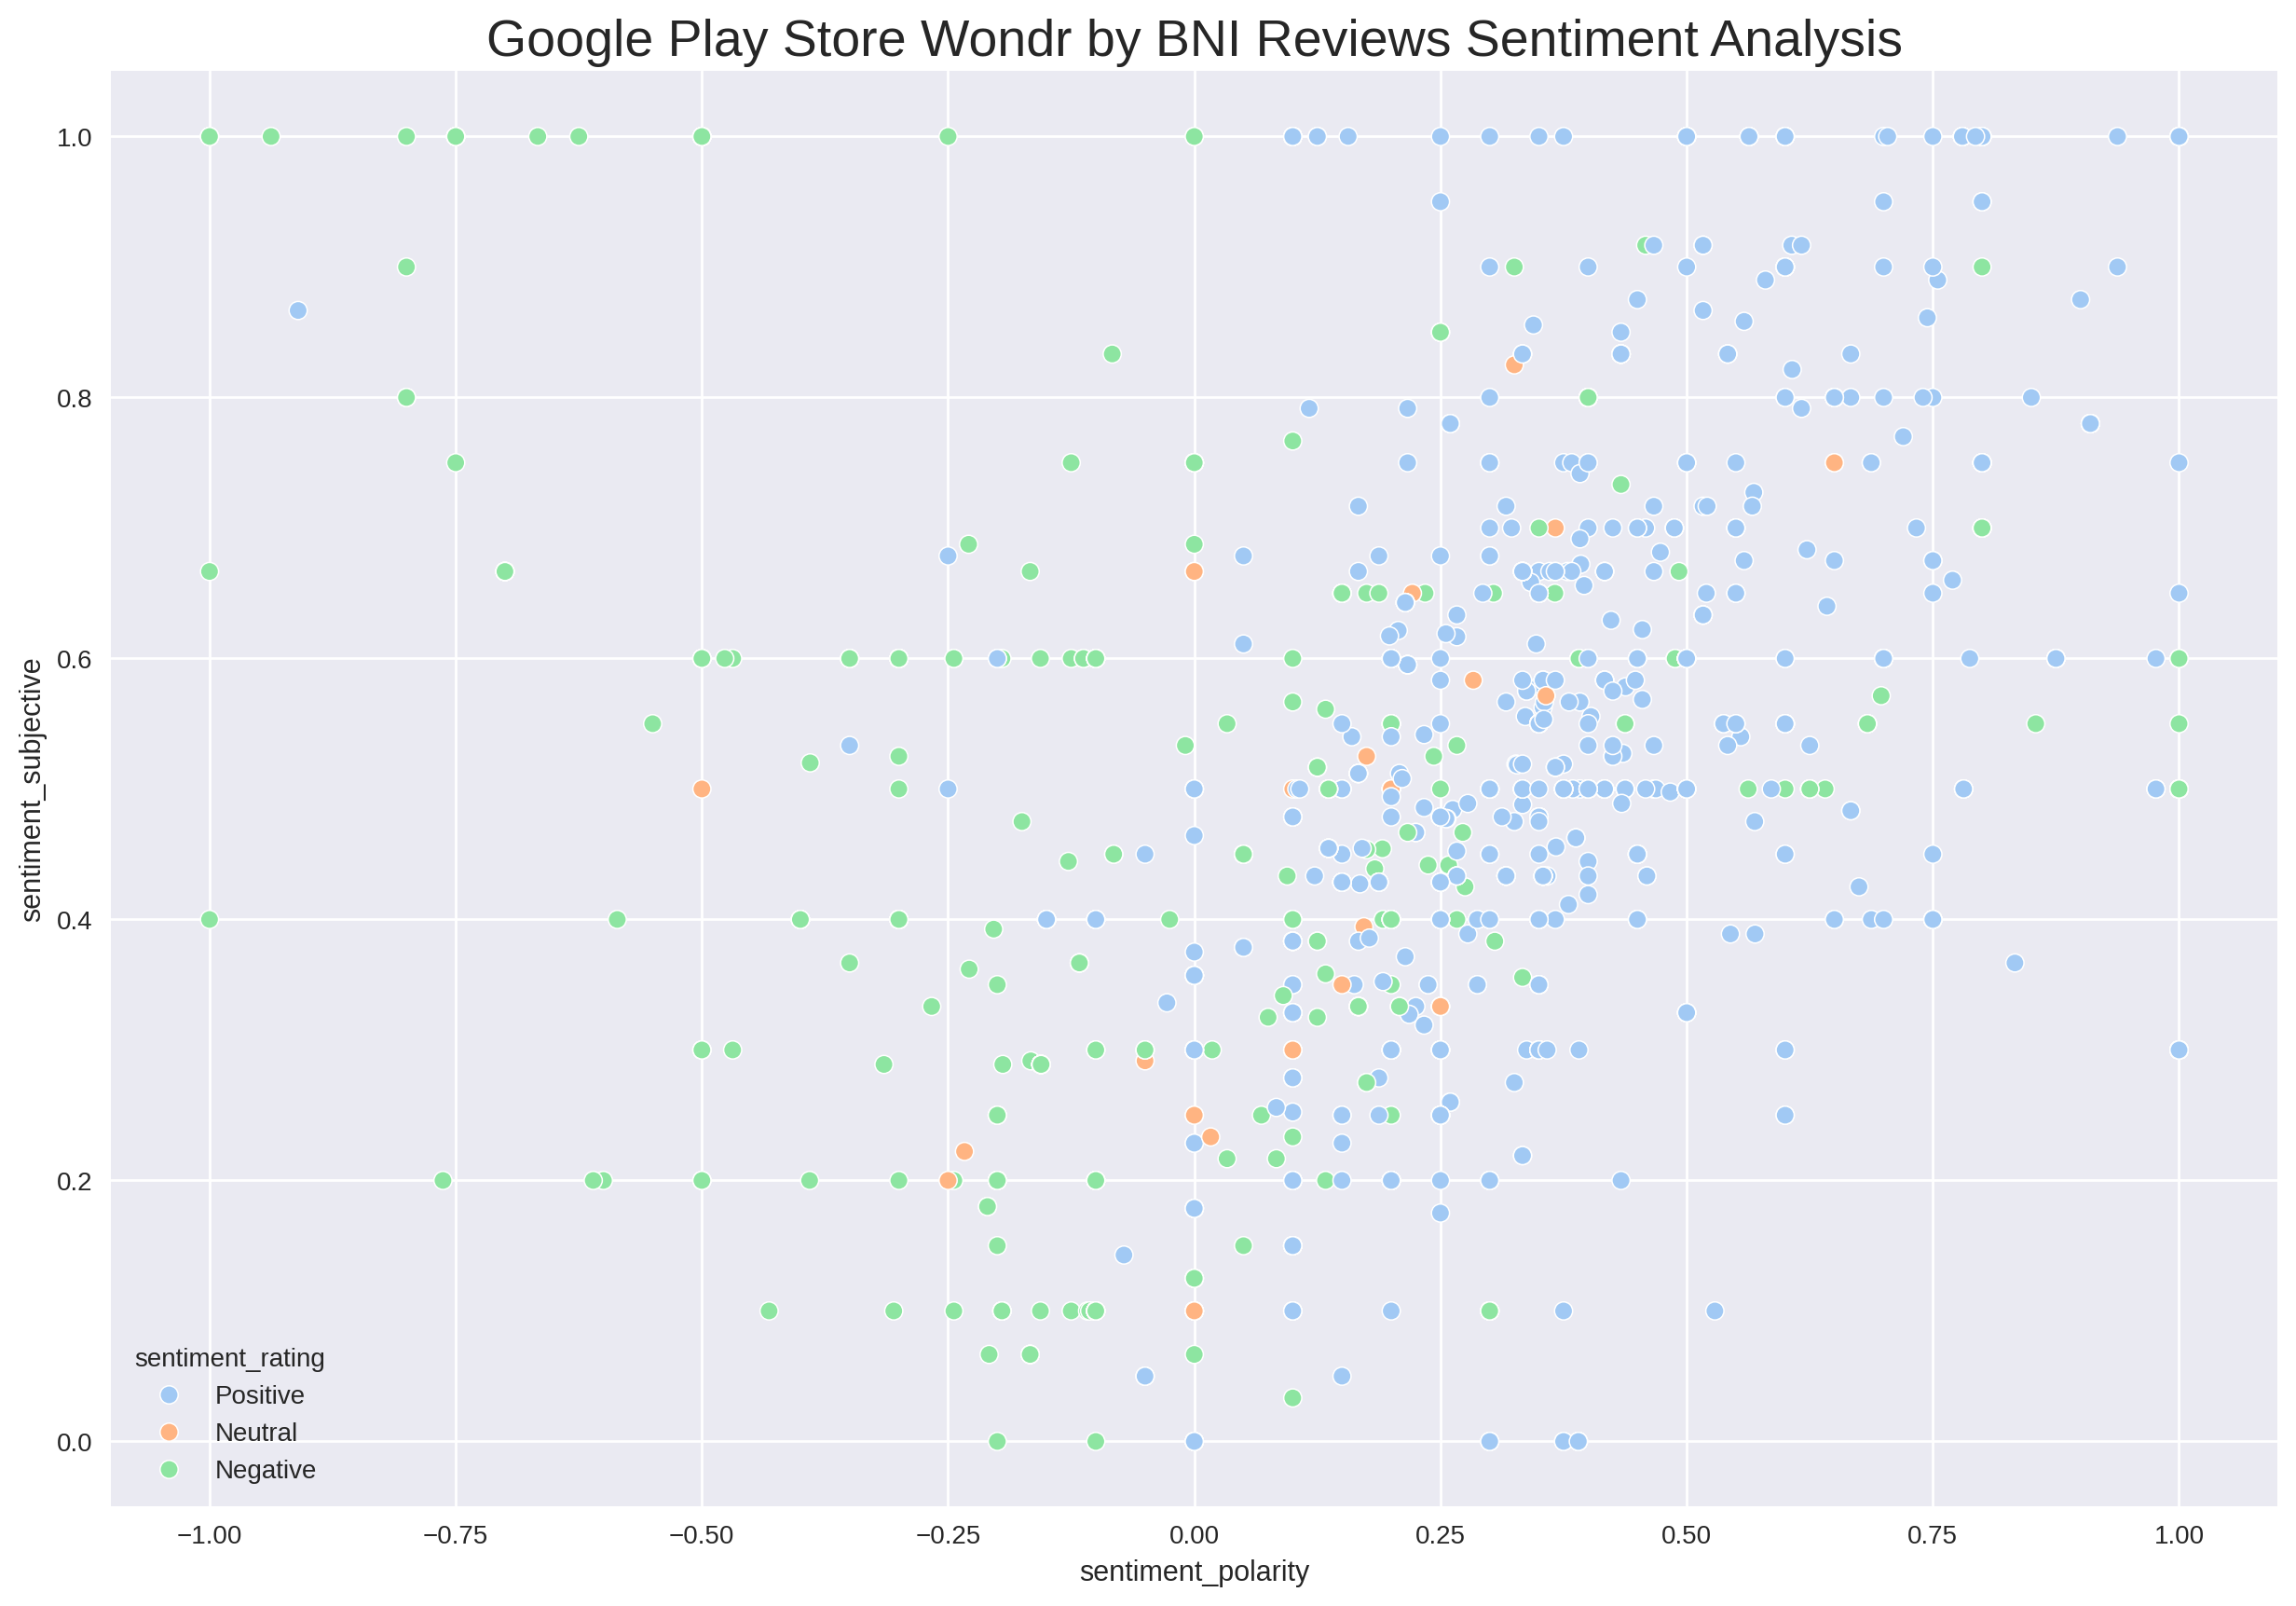

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
sns.scatterplot(
    x=df_wondrrev['sentiment_polarity'],
    y=df_wondrrev['sentiment_subjective'],
    hue=df_wondrrev['sentiment_rating'],
    edgecolor='white',
    palette="pastel"
)
plt.title("Google Play Store Wondr by BNI Reviews Sentiment Analysis", fontsize=20)
plt.show()


In [25]:
# Print the extracted emojis review column (content) before stopwords
df_wondrrev.to_csv(r'C:\Users\Hafidz\PhDwork\APPREV\df_wondrrev_before_stopwords_sentiment_rating.csv', index=False)


In [26]:
import nltk
from nltk.corpus import stopwords
stop = stopwords.words('english') + ["someone","still","would","need"]
print(stop)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [27]:
print(len(stop))

202


In [28]:
df_wondrrev_stopwords = df_wondrrev.loc[:, ["content","score","sentiment_polarity",
                                            "sentiment_subjective","sentiment_rating"]]

In [29]:
# Exclude stopwords
df_wondrrev_stopwords['tweet_without_stopwords'] = df_wondrrev_stopwords['content'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop])
)
print(df_wondrrev_stopwords)


                                                                                              content  \
0                                                                                               bagus   
1                                                                                              mantap   
2                                                                             bermanfaat cepat akurat   
3                                                                              sangat membantu sekali   
4                                                                                                bgus   
...                                                                                               ...   
88798                                                                                  simpel..mantab   
88799  makin simple dan lengkap. terkoneksi dengan all sumber dana baik debet dan kredit. makin keren   
88800                                                  

In [30]:
pat = r'\b(?:{})\b'.format('|'.join(stop))
df_wondrrev_stopwords['tweet_without_stopwords'] = df_wondrrev_stopwords['content'].str.replace(pat, '', regex=True)
df_wondrrev_stopwords['tweet_without_stopwords'] = df_wondrrev_stopwords['tweet_without_stopwords'].str.replace(r'\s+', ' ', regex=True)


In [31]:
# Save into csv after applying stopwords
df_wondrrev_stopwords.to_csv(
    r'C:\Users\Hafidz\PhDwork\APPREV\df_wondrrev_after_stopwords_sentiment_rating2.csv',
    index=False
)


In [32]:
# Count after stopwords
import string

df_wondrrev_stopwords['wordCount'] = [len(review.split()) for review in df_wondrrev_stopwords['content']]
df_wondrrev_stopwords['wordCount_after_stopwords'] = [len(review.split()) for review in df_wondrrev_stopwords['tweet_without_stopwords']]



In [33]:
df_wondrrev_stopwords.loc[:, ["content","score","sentiment_polarity",
                              "sentiment_rating","wordCount",
                              "tweet_without_stopwords",
                              "wordCount_after_stopwords"]]


,content,score,sentiment_polarity,sentiment_rating,wordCount,tweet_without_stopwords,wordCount_after_stopwords
0,bagus,5,0.0,Positive,1,bagus,1
1,mantap,5,0.0,Positive,1,mantap,1
2,bermanfaat cepat akurat,5,0.0,Positive,3,bermanfaat cepat akurat,3
3,sangat membantu sekali,5,0.0,Positive,3,sangat membantu sekali,3
4,bgus,5,0.0,Positive,1,bgus,1
...,...,...,...,...,...,...,...
88798,simpel..mantab,5,0.0,Positive,1,simpel..mantab,1
88799,makin simple dan lengkap. terkoneksi dengan all sumber dana baik debet dan kredit. makin keren,5,0.0,Positive,15,makin simple dan lengkap. terkoneksi dengan sumber dana baik debet dan kredit. makin keren,14
88800,tampilannya keren👏👏,5,0.0,Positive,2,tampilannya keren👏👏,2
88801,canggih...,5,0.0,Positive,1,canggih...,1


In [34]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  ax = sns.barplot(data=d, x= "word", y = "count")
  ax.set(ylabel = 'Count')
  plt.show()

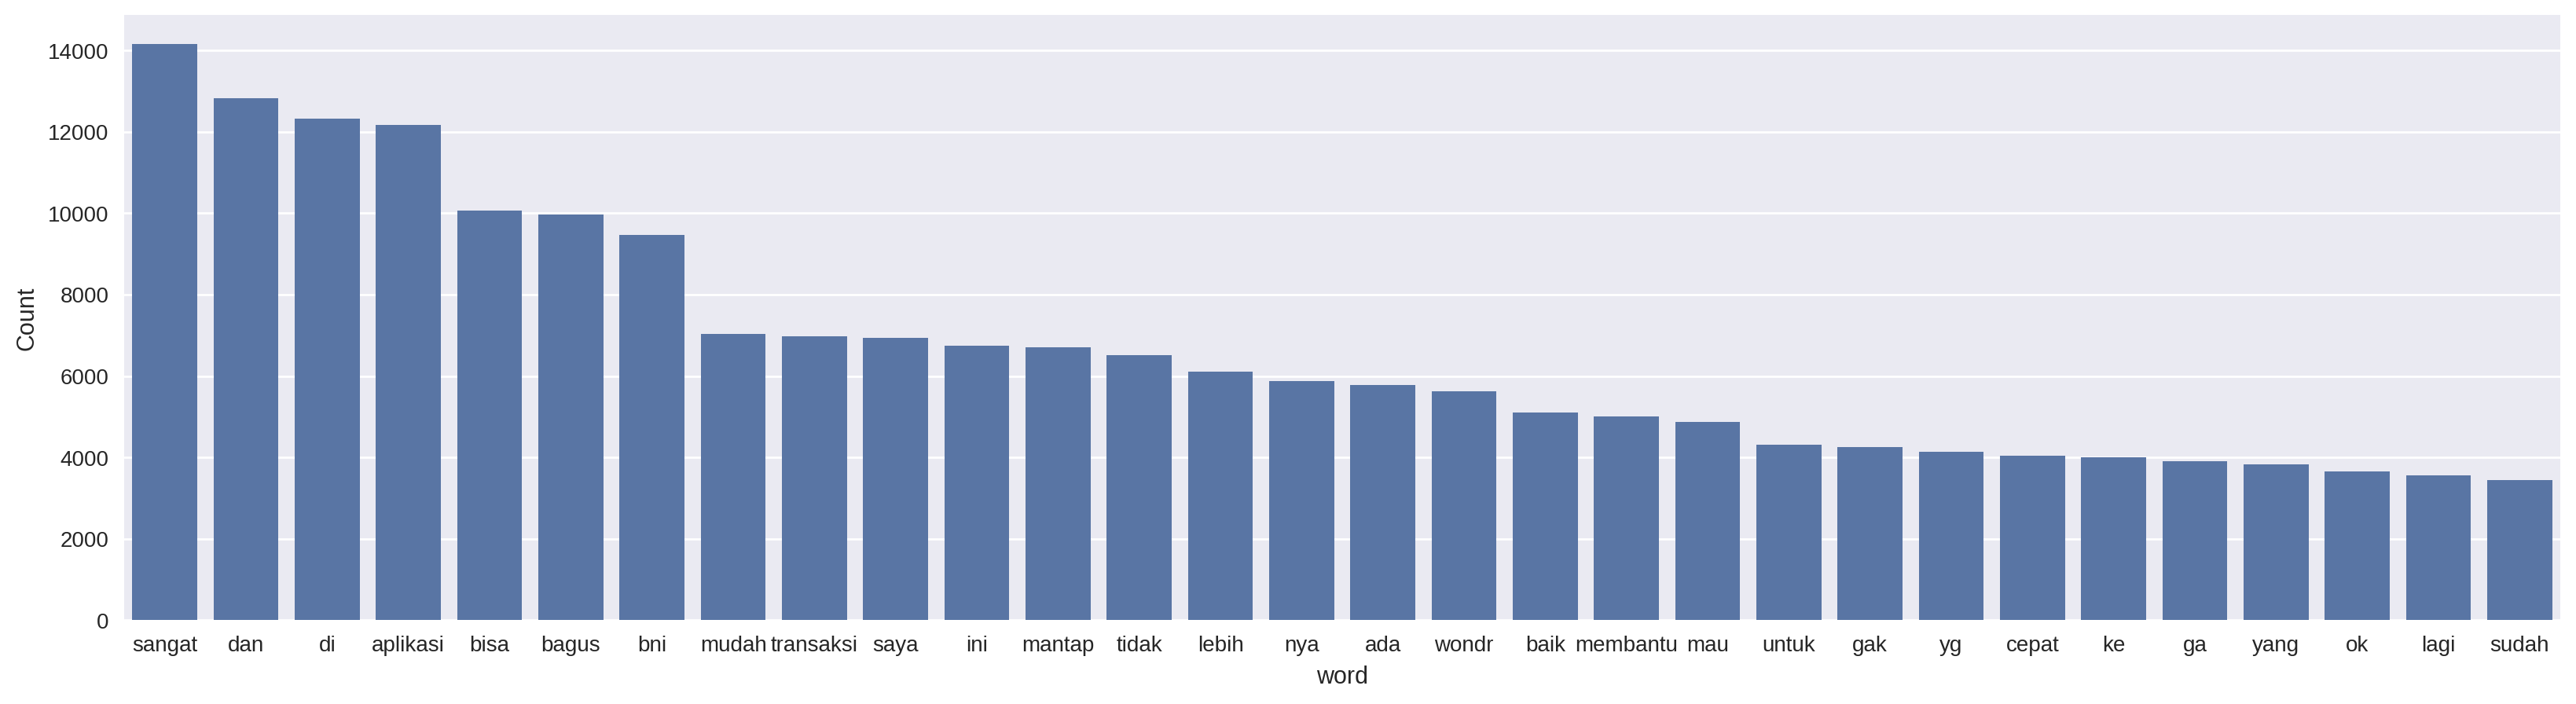

In [35]:
freq_words(df_wondrrev_stopwords['tweet_without_stopwords'])

In [36]:
newStopWords = ["'",".",",", "someone","still","would","need"]

#from nltk.corpus import stopwords
#stoplist = stopwords.words('english') + ['though']

#NOT YET DONE ==== 24 May 2022

In [37]:
# Stemming

# Stemming function chops off the end of the word
# and transform the word into its root form.
# All suffixes like -s, -es, -ed, -ing are removed.

from nltk.stem import PorterStemmer

def stemming(x):
    st = PorterStemmer()
    if x is not None:
        return ' '.join([st.stem(word) for word in x.split()])
    else:
        return ''

# Terapkan ke kolom tweet_without_stopwords
df_wondrrev_stopwords['tweet_stemmed'] = df_wondrrev_stopwords['tweet_without_stopwords'].apply(lambda x: stemming(x))

# Contoh print hasil stemming pada baris tertentu
print(df_wondrrev_stopwords['tweet_stemmed'].iloc[22439])


mantap wondr bni ini. saya suka saya suka


In [38]:
#===BIGRAM https://towardsdatascience.com/text-analysis-basics-in-python-443282942ec5 not yet
#Creating bigram/trigram to search

In [39]:
# DROP NA untuk menghapus baris yang ada nilai kosong
df_wondrrev_stopwords.dropna(inplace=True)

# Cek informasi dataframe setelah baris kosong dihapus
df_wondrrev_stopwords.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88803 entries, 0 to 88802
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   content                    88803 non-null  object 
 1   score                      88803 non-null  int64  
 2   sentiment_polarity         88803 non-null  float64
 3   sentiment_subjective       88803 non-null  float64
 4   sentiment_rating           88803 non-null  object 
 5   tweet_without_stopwords    88803 non-null  object 
 6   wordCount                  88803 non-null  int64  
 7   wordCount_after_stopwords  88803 non-null  int64  
 8   tweet_stemmed              88803 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.1+ MB


In [40]:
df_wondrrev_stopwords.loc[:, ["content","score","sentiment_rating",
                              "wordCount","tweet_without_stopwords",
                              "wordCount_after_stopwords"]]


,content,score,sentiment_rating,wordCount,tweet_without_stopwords,wordCount_after_stopwords
0,bagus,5,Positive,1,bagus,1
1,mantap,5,Positive,1,mantap,1
2,bermanfaat cepat akurat,5,Positive,3,bermanfaat cepat akurat,3
3,sangat membantu sekali,5,Positive,3,sangat membantu sekali,3
4,bgus,5,Positive,1,bgus,1
...,...,...,...,...,...,...
88798,simpel..mantab,5,Positive,1,simpel..mantab,1
88799,makin simple dan lengkap. terkoneksi dengan all sumber dana baik debet dan kredit. makin keren,5,Positive,15,makin simple dan lengkap. terkoneksi dengan sumber dana baik debet dan kredit. makin keren,14
88800,tampilannya keren👏👏,5,Positive,2,tampilannya keren👏👏,2
88801,canggih...,5,Positive,1,canggih...,1
